# TrustLens — Day 2: EDA and Preprocessing
**Project:** Trust Calibration, Decision Agency, and Fairness Perception Across Explanation Modalities

Run each cell using **Shift + Enter**

## Cell 1 — Install and Import Libraries

In [1]:
!pip install openpyxl -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import joblib
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.1)
print('All libraries loaded successfully!')

All libraries loaded successfully!


## Cell 2 — Upload Your Dataset

In [2]:
from google.colab import files
print('Upload: german_credit_with_codebook__TrustLens_.xlsx')
uploaded = files.upload()
filename = list(uploaded.keys())[0]
print(f'Uploaded: {filename}')

Upload: german_credit_with_codebook__TrustLens_.xlsx


Saving german_credit_with_codebook (TrustLens).xlsx to german_credit_with_codebook (TrustLens).xlsx
Uploaded: german_credit_with_codebook (TrustLens).xlsx


## Cell 3 — Load Both Sheets

In [3]:
df_raw      = pd.read_excel(filename, sheet_name='German Credit Data')
df_codebook = pd.read_excel(filename, sheet_name='Codebook')

print(f'Dataset:  {df_raw.shape[0]} rows, {df_raw.shape[1]} columns')
print(f'Codebook: {df_codebook.shape[0]} entries')
print(f'Missing:  {df_raw.isnull().sum().sum()} values')
df_raw.head(3)

Dataset:  1000 rows, 21 columns
Codebook: 75 entries
Missing:  0 values


,checking_account_status,duration_months,credit_history,purpose,credit_amount,savings_account_bonds,employment_since,installment_rate_percent_disposable_income,personal_status_sex,other_debtors_guarantors,...,property,age_years,other_installment_plans,housing,existing_credits_at_bank,job,people_liable_for_maintenance,telephone,foreign_worker,credit_risk
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1


## Cell 4 — Decode A-Codes into Readable Labels

In [4]:
# Fix column name mismatches between codebook and data
column_name_fix = {
    'savings_account':  'savings_account_bonds',
    'other_debtors':    'other_debtors_guarantors'
}

# Build decode map — exclude credit_risk (handled separately)
valid_cols = set(df_raw.columns) - {'credit_risk'}
decode_map = {}

for _, row in df_codebook.iterrows():
    col   = str(row['Column']).strip()
    code  = str(row['Code']).strip()
    label = str(row['Meaning / Readable Label']).strip()
    col   = column_name_fix.get(col, col)
    if col in valid_cols and code not in ['nan',''] and label not in ['nan','']:
        if col not in decode_map: decode_map[col] = {}
        decode_map[col][code] = label

df = df_raw.copy()
for col, mapping in decode_map.items():
    df[col] = df[col].astype(str).map(mapping).fillna(df[col].astype(str))

# Decode target separately
df['credit_risk'] = df['credit_risk'].map({1: 'Good', 2: 'Bad'})

print('Decoding complete. Sample:')
df[['checking_account_status','savings_account_bonds','foreign_worker','credit_risk']].head(5)

Decoding complete. Sample:


,checking_account_status,savings_account_bonds,foreign_worker,credit_risk
0,< 0 DM,unknown / no savings account,yes,Good
1,0 <= balance < 200 DM,< 100 DM,yes,Bad
2,no checking account,< 100 DM,yes,Good
3,< 0 DM,< 100 DM,yes,Good
4,< 0 DM,< 100 DM,yes,Bad


## Cell 5 — EDA: Class Distribution

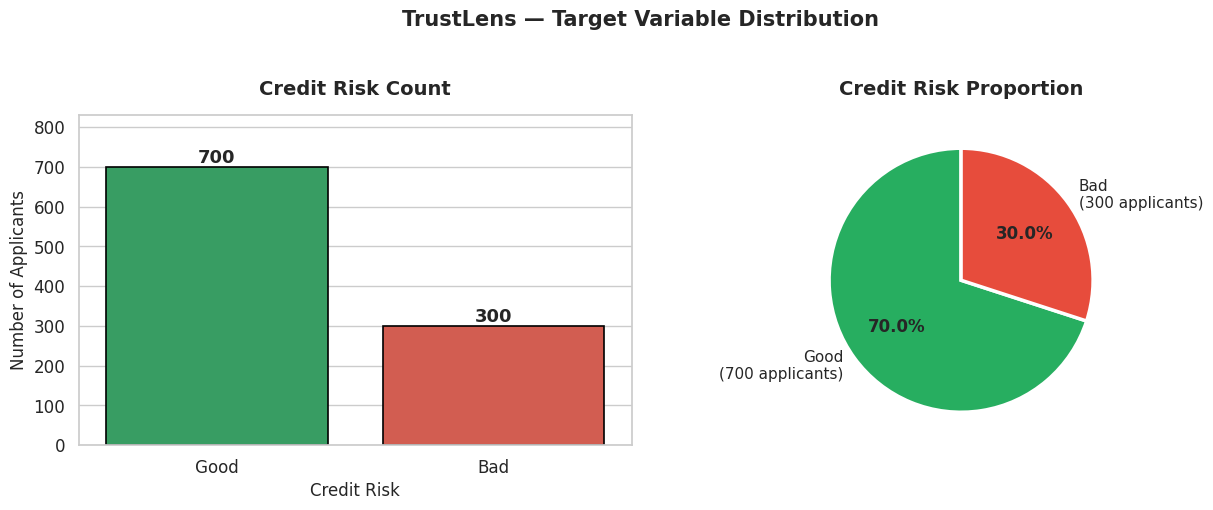

Good: 700 (70.0%)
Bad:  300 (30.0%)


In [5]:
palette = {'Good': '#27ae60', 'Bad': '#e74c3c'}
counts  = df['credit_risk'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart
sns.countplot(data=df, x='credit_risk', ax=axes[0],
              palette=palette, edgecolor='black', linewidth=1.2)
axes[0].set_title('Credit Risk Count', fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel('Credit Risk', fontsize=12)
axes[0].set_ylabel('Number of Applicants', fontsize=12)
axes[0].set_ylim(0, 830)
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}',
                     (p.get_x() + p.get_width()/2., p.get_height()),
                     ha='center', va='bottom', fontsize=13, fontweight='bold')

# Pie chart
wedges, texts, autotexts = axes[1].pie(
    counts.values,
    labels=[f'{k}\n({v} applicants)' for k,v in counts.items()],
    autopct='%1.1f%%',
    colors=[palette[k] for k in counts.index],
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2.5),
    textprops={'fontsize': 11}
)
for at in autotexts:
    at.set_fontweight('bold')
    at.set_fontsize(12)
axes[1].set_title('Credit Risk Proportion', fontsize=14, fontweight='bold', pad=15)

plt.suptitle('TrustLens — Target Variable Distribution', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Good: {counts["Good"]} ({counts["Good"]/len(df)*100:.1f}%)')
print(f'Bad:  {counts["Bad"]} ({counts["Bad"]/len(df)*100:.1f}%)')

## Cell 6 — EDA: Fairness-Sensitive Features (RQ3)
**Research note:** These are demographic proxies that SHAP may surface in Condition C, triggering fairness perception in participants.

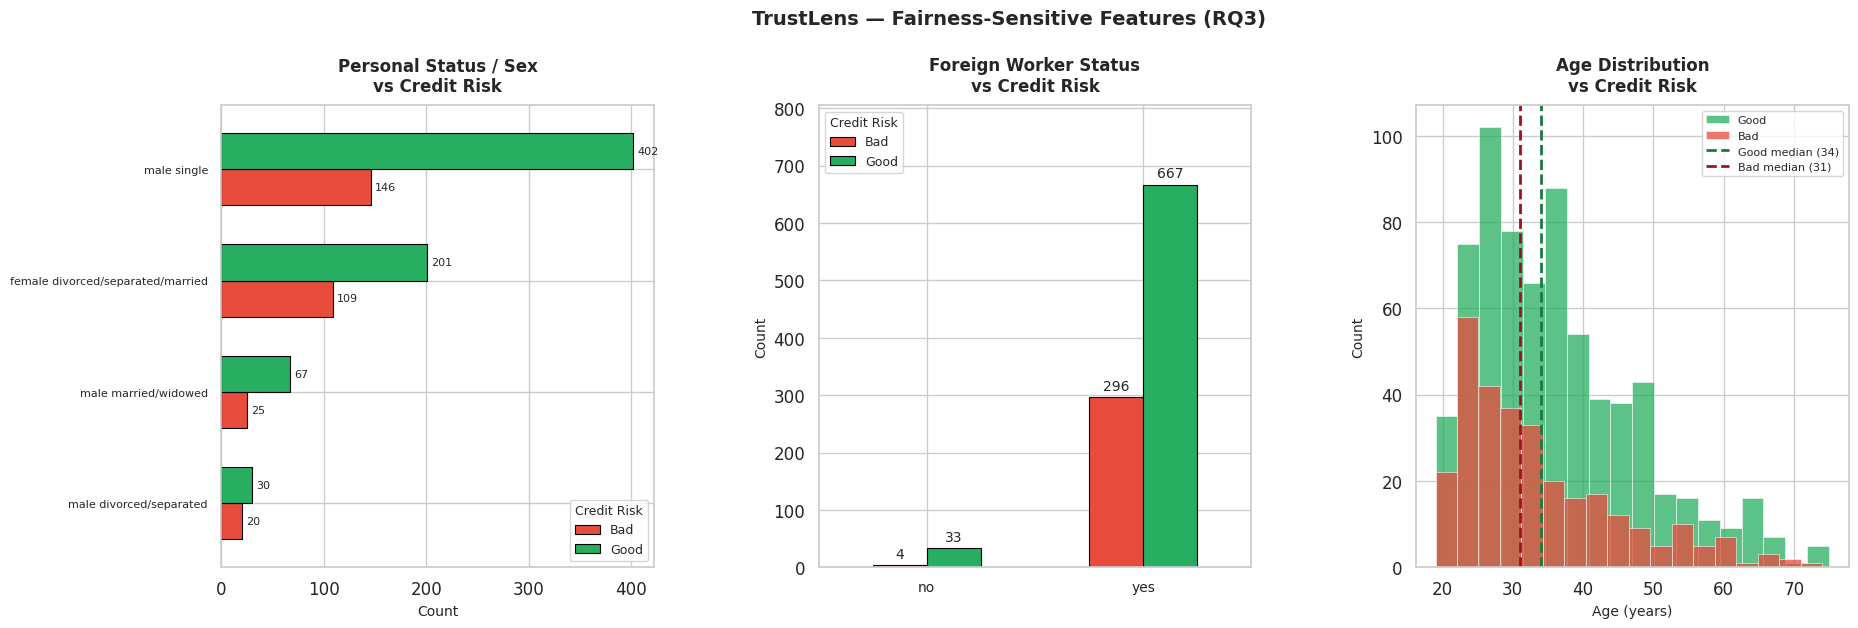

RQ3 insight: SHAP may surface personal_status_sex and foreign_worker — watch for fairness perception shifts in participants.


In [6]:
fig = plt.figure(figsize=(21, 6))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.38)

# --- Personal Status / Sex (horizontal bar) ---
ax1 = fig.add_subplot(gs[0])
ps_pivot = df.groupby(['personal_status_sex','credit_risk']).size().unstack(fill_value=0)
ps_pivot.sort_values('Good', ascending=True).plot(
    kind='barh', ax=ax1,
    color=['#e74c3c','#27ae60'], edgecolor='black', linewidth=0.8, width=0.65
)
ax1.set_title('Personal Status / Sex\nvs Credit Risk', fontsize=12, fontweight='bold', pad=10)
ax1.set_xlabel('Count', fontsize=10)
ax1.set_ylabel('')
ax1.tick_params(axis='y', labelsize=8)
ax1.legend(title='Credit Risk', fontsize=9, title_fontsize=9)
for container in ax1.containers:
    ax1.bar_label(container, fontsize=8, padding=3)

# --- Foreign Worker (vertical bar) ---
ax2 = fig.add_subplot(gs[1])
fw_pivot = df.groupby(['foreign_worker','credit_risk']).size().unstack(fill_value=0)
fw_pivot.plot(
    kind='bar', ax=ax2,
    color=['#e74c3c','#27ae60'], edgecolor='black', linewidth=0.8, width=0.5
)
ax2.set_title('Foreign Worker Status\nvs Credit Risk', fontsize=12, fontweight='bold', pad=10)
ax2.set_xlabel('')
ax2.set_ylabel('Count', fontsize=10)
ax2.tick_params(axis='x', rotation=0, labelsize=10)
ax2.legend(title='Credit Risk', fontsize=9, title_fontsize=9)
ax2.set_ylim(0, ax2.get_ylim()[1] * 1.15)
for container in ax2.containers:
    ax2.bar_label(container, fontsize=10, padding=3)

# --- Age Distribution (histogram with medians) ---
ax3 = fig.add_subplot(gs[2])
good_ages = df[df['credit_risk']=='Good']['age_years']
bad_ages  = df[df['credit_risk']=='Bad']['age_years']
ax3.hist(good_ages, bins=18, alpha=0.75, color='#27ae60',
         label='Good', edgecolor='white', linewidth=0.5)
ax3.hist(bad_ages,  bins=18, alpha=0.75, color='#e74c3c',
         label='Bad',  edgecolor='white', linewidth=0.5)
ax3.axvline(good_ages.median(), color='#1a7a40', linestyle='--',
            linewidth=2, label=f'Good median ({int(good_ages.median())})')
ax3.axvline(bad_ages.median(),  color='#a01020', linestyle='--',
            linewidth=2, label=f'Bad median ({int(bad_ages.median())})')
ax3.set_title('Age Distribution\nvs Credit Risk', fontsize=12, fontweight='bold', pad=10)
ax3.set_xlabel('Age (years)', fontsize=10)
ax3.set_ylabel('Count', fontsize=10)
ax3.legend(fontsize=8)

plt.suptitle('TrustLens — Fairness-Sensitive Features (RQ3)',
             fontsize=14, fontweight='bold', y=1.04)
plt.savefig('fairness_features.png', dpi=150, bbox_inches='tight')
plt.show()
print('RQ3 insight: SHAP may surface personal_status_sex and foreign_worker — watch for fairness perception shifts in participants.')

## Cell 7 — EDA: Key Financial Features

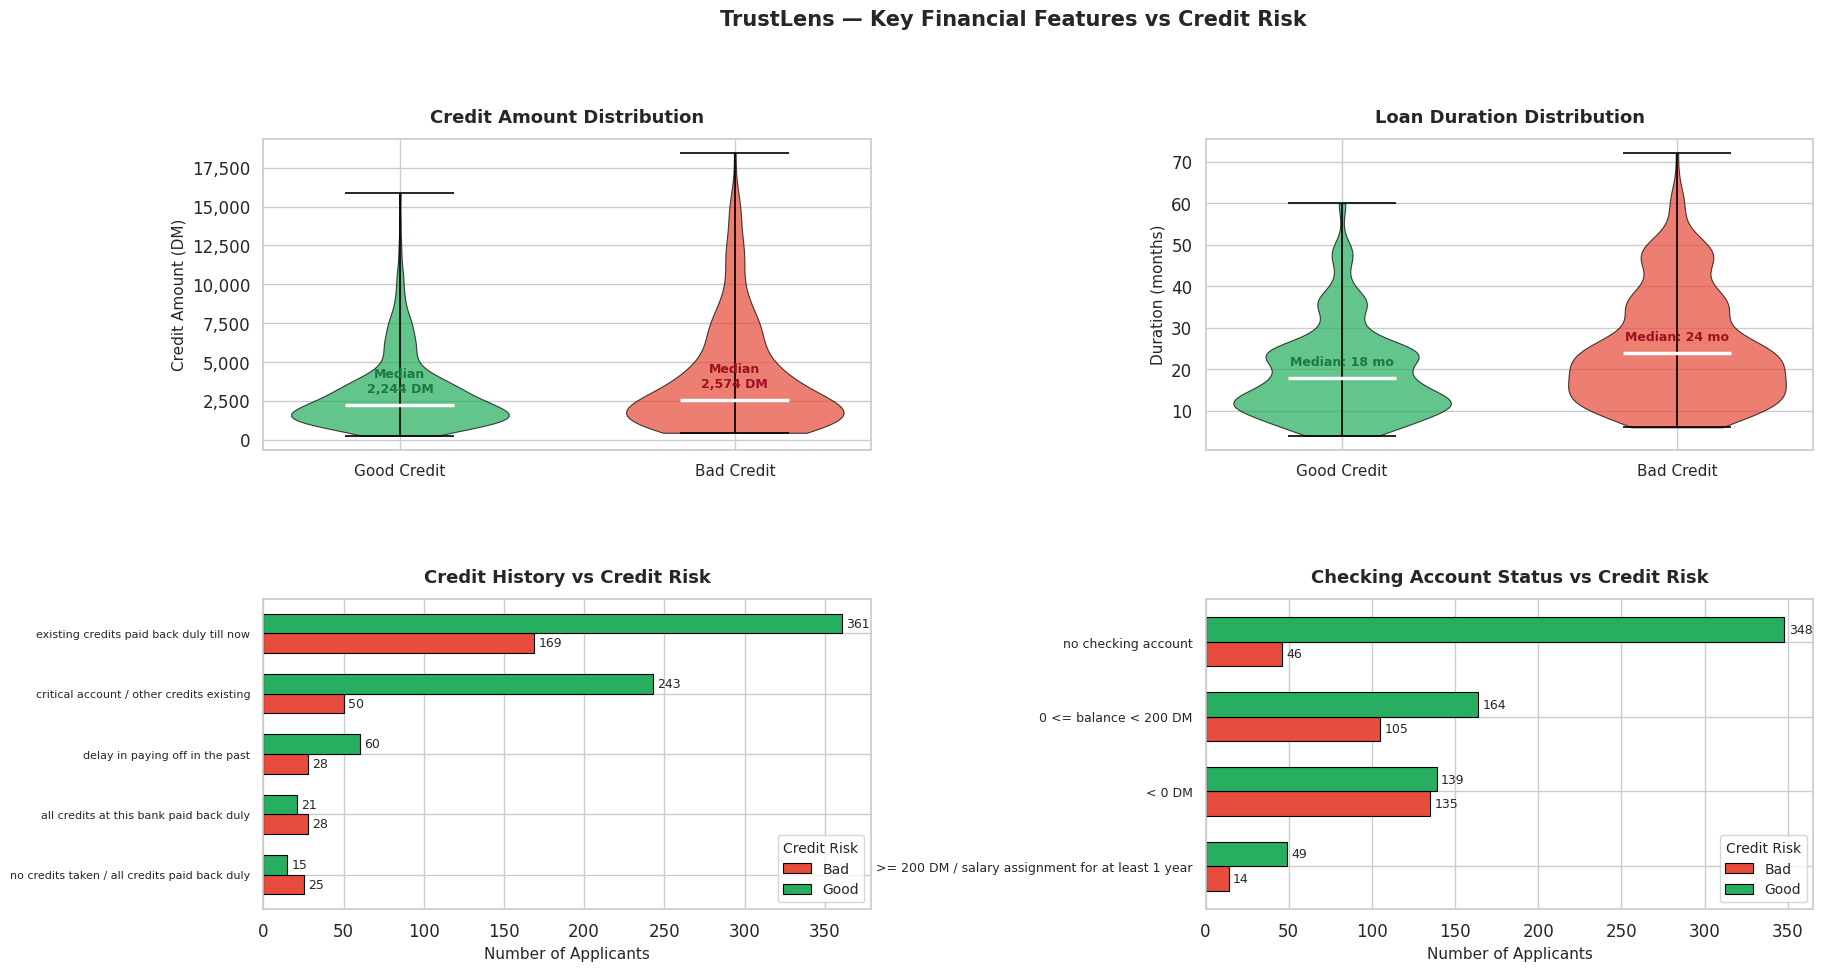

In [7]:
fig = plt.figure(figsize=(20, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.48, wspace=0.55)

# --- Top Left: Credit Amount (violin plot) ---
ax1 = fig.add_subplot(gs[0, 0])
good_amt = df[df['credit_risk']=='Good']['credit_amount']
bad_amt  = df[df['credit_risk']=='Bad']['credit_amount']
parts = ax1.violinplot([good_amt, bad_amt], positions=[1, 2],
                       showmedians=True, showextrema=True, widths=0.65)
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(['#27ae60','#e74c3c'][i])
    pc.set_alpha(0.72)
    pc.set_edgecolor('black')
    pc.set_linewidth(0.8)
parts['cmedians'].set_colors('white')
parts['cmedians'].set_linewidth(2.5)
for part in ['cmins','cmaxes','cbars']:
    parts[part].set_colors('black')
    parts[part].set_linewidth(1.2)
ax1.set_xticks([1, 2])
ax1.set_xticklabels(['Good Credit', 'Bad Credit'], fontsize=11)
ax1.set_title('Credit Amount Distribution', fontsize=13, fontweight='bold', pad=12)
ax1.set_ylabel('Credit Amount (DM)', fontsize=11)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{int(x):,}'))
ax1.text(1, good_amt.median()+800, f'Median\n{int(good_amt.median()):,} DM',
         ha='center', fontsize=9, color='#1a7a40', fontweight='bold')
ax1.text(2, bad_amt.median()+800,  f'Median\n{int(bad_amt.median()):,} DM',
         ha='center', fontsize=9, color='#a01020', fontweight='bold')

# --- Top Right: Loan Duration (violin plot) ---
ax2 = fig.add_subplot(gs[0, 1])
good_dur = df[df['credit_risk']=='Good']['duration_months']
bad_dur  = df[df['credit_risk']=='Bad']['duration_months']
parts2 = ax2.violinplot([good_dur, bad_dur], positions=[1, 2],
                        showmedians=True, showextrema=True, widths=0.65)
for i, pc in enumerate(parts2['bodies']):
    pc.set_facecolor(['#27ae60','#e74c3c'][i])
    pc.set_alpha(0.72)
    pc.set_edgecolor('black')
    pc.set_linewidth(0.8)
parts2['cmedians'].set_colors('white')
parts2['cmedians'].set_linewidth(2.5)
for part in ['cmins','cmaxes','cbars']:
    parts2[part].set_colors('black')
    parts2[part].set_linewidth(1.2)
ax2.set_xticks([1, 2])
ax2.set_xticklabels(['Good Credit', 'Bad Credit'], fontsize=11)
ax2.set_title('Loan Duration Distribution', fontsize=13, fontweight='bold', pad=12)
ax2.set_ylabel('Duration (months)', fontsize=11)
ax2.text(1, good_dur.median()+3, f'Median: {int(good_dur.median())} mo',
         ha='center', fontsize=9, color='#1a7a40', fontweight='bold')
ax2.text(2, bad_dur.median()+3,  f'Median: {int(bad_dur.median())} mo',
         ha='center', fontsize=9, color='#a01020', fontweight='bold')

# --- Bottom Left: Credit History (horizontal bar) ---
ax3 = fig.add_subplot(gs[1, 0])
ch = df.groupby(['credit_history','credit_risk']).size().unstack(fill_value=0)
ch.sort_values('Good', ascending=True).plot(
    kind='barh', ax=ax3,
    color=['#e74c3c','#27ae60'], edgecolor='black', linewidth=0.8, width=0.65
)
ax3.set_title('Credit History vs Credit Risk', fontsize=13, fontweight='bold', pad=12)
ax3.set_xlabel('Number of Applicants', fontsize=11)
ax3.set_ylabel('')
ax3.tick_params(axis='y', labelsize=8)
ax3.legend(title='Credit Risk', fontsize=10, title_fontsize=10, loc='lower right')
for container in ax3.containers:
    ax3.bar_label(container, fontsize=9, padding=3)

# --- Bottom Right: Checking Account (horizontal bar) ---
ax4 = fig.add_subplot(gs[1, 1])
ca = df.groupby(['checking_account_status','credit_risk']).size().unstack(fill_value=0)
ca.sort_values('Good', ascending=True).plot(
    kind='barh', ax=ax4,
    color=['#e74c3c','#27ae60'], edgecolor='black', linewidth=0.8, width=0.65
)
ax4.set_title('Checking Account Status vs Credit Risk', fontsize=13, fontweight='bold', pad=12)
ax4.set_xlabel('Number of Applicants', fontsize=11)
ax4.set_ylabel('')
ax4.tick_params(axis='y', labelsize=9)
ax4.legend(title='Credit Risk', fontsize=10, title_fontsize=10, loc='lower right')
for container in ax4.containers:
    ax4.bar_label(container, fontsize=9, padding=3)

plt.suptitle('TrustLens — Key Financial Features vs Credit Risk',
             fontsize=15, fontweight='bold', y=1.01)
plt.savefig('financial_features.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 8 — Preprocessing Pipeline

In [8]:
df_proc = df.copy()

# Step 1: Binary target
df_proc['credit_risk'] = df_proc['credit_risk'].map({'Good': 0, 'Bad': 1})

# Step 2: Identify columns reliably across all pandas versions
cat_cols = [c for c in df_proc.columns
            if c != 'credit_risk' and df_proc[c].dtype not in ['int64','float64']]
num_cols = [c for c in df_proc.columns
            if c != 'credit_risk' and df_proc[c].dtype in ['int64','float64']]

print(f'Categorical ({len(cat_cols)}): {cat_cols}')
print(f'Numerical   ({len(num_cols)}): {num_cols}')

# Step 3: Label encode categoricals
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df_proc[col] = le.fit_transform(df_proc[col].astype(str))
    label_encoders[col] = le

# Step 4: Separate X and y
X = df_proc.drop('credit_risk', axis=1)
y = df_proc['credit_risk']

print(f'\nFeatures: {X.shape} | Target: {y.shape}')
print(f'NaN check: {X.isnull().sum().sum()} in X, {y.isnull().sum()} in y')
print(f'Balance: Good={sum(y==0)}, Bad={sum(y==1)}')

Categorical (13): ['checking_account_status', 'credit_history', 'purpose', 'savings_account_bonds', 'employment_since', 'personal_status_sex', 'other_debtors_guarantors', 'property', 'other_installment_plans', 'housing', 'job', 'telephone', 'foreign_worker']
Numerical   (7): ['duration_months', 'credit_amount', 'installment_rate_percent_disposable_income', 'residence_since_years', 'age_years', 'existing_credits_at_bank', 'people_liable_for_maintenance']

Features: (1000, 20) | Target: (1000,)
NaN check: 0 in X, 0 in y
Balance: Good=700, Bad=300


## Cell 9 — Train/Test Split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set : {X_train.shape[0]} rows | Good={sum(y_train==0)}, Bad={sum(y_train==1)}')
print(f'Test set     : {X_test.shape[0]} rows  | Good={sum(y_test==0)},  Bad={sum(y_test==1)}')
print('\nStratified split complete!')

Training set : 800 rows | Good=560, Bad=240
Test set     : 200 rows  | Good=140,  Bad=60

Stratified split complete!


## Cell 10 — Save All Files

In [10]:
X_train.to_csv('X_train.csv', index=False)
X_test.to_csv('X_test.csv', index=False)
y_train.to_csv('y_train.csv', index=False)
y_test.to_csv('y_test.csv', index=False)
df_proc.to_csv('german_credit_processed.csv', index=False)
joblib.dump(label_encoders, 'label_encoders.pkl')
joblib.dump(list(X.columns), 'feature_names.pkl')

print('Saved:')
print('  X_train.csv, X_test.csv, y_train.csv, y_test.csv  -> data/processed/')
print('  german_credit_processed.csv                        -> data/processed/')
print('  label_encoders.pkl, feature_names.pkl              -> models/')
print('  *.png charts                                        -> analysis/charts/')

Saved:
  X_train.csv, X_test.csv, y_train.csv, y_test.csv  -> data/processed/
  german_credit_processed.csv                        -> data/processed/
  label_encoders.pkl, feature_names.pkl              -> models/
  *.png charts                                        -> analysis/charts/


## Cell 11 — Download All Files

In [11]:
from google.colab import files
import os

all_files = [
    'X_train.csv','X_test.csv','y_train.csv','y_test.csv',
    'german_credit_processed.csv','label_encoders.pkl','feature_names.pkl',
    'target_distribution.png','fairness_features.png','financial_features.png'
]

for f in all_files:
    if os.path.exists(f):
        files.download(f)
        print(f'Downloaded: {f}')
    else:
        print(f'Not found (skipped): {f}')

print('\nDay 2 complete!')
print('Next: git add . && git commit -m "Day 2: EDA + preprocessing" && git push')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: X_train.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Downloaded: fairness_features.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: financial_features.png

Day 2 complete!
Next: git add . && git commit -m "Day 2: EDA + preprocessing" && git push
